# Stock Market Analysis & Price Prediction Using Machine Learning

**Author:** Aneesa Alam  
**Date:** 10th March 2026  
**Project Goal:** Analyze 5 years of stock market data for major tech companies and build ML models to predict future prices

## Project Overview

This notebook performs comprehensive analysis on stock market data including:
- Data collection from Yahoo Finance
- Feature engineering with 40+ technical indicators
- Exploratory data analysis with professional visualizations
- Machine learning models for price prediction
- Model evaluation and comparison

**Companies Analyzed:** Apple, Microsoft, Google, Tesla, Amazon  
**Time Period:** 5 years of historical data  
**Target:** Predict next day's closing price

## PROJECT SETUP

**Purpose:** Initialize project structure in Google Drive

**What this does:**
- Connects notebook to your Google Drive
- Creates organized folder structure for data and outputs
- Saves project path for use throughout the notebook

**Folder Structure:**
- stock_market_analysis/
  - data/
    - raw/ (Original downloaded data)
    - processed/ (Cleaned data with features)
  - outputs/
    - figures/ (All charts and visualizations)
    - models/ (Saved ML models)

**Expected Output:** "Project structure created!" message

In [ ]:
# PROJECT SETUP
# Purpose: Create project folder structure in Google Drive

from google.colab import drive
drive.mount('/content/drive')  # Connect to Google Drive

import os

# Define project name
PROJECT_NAME = "stock_market_analysis"
base_path = f'/content/drive/MyDrive/{PROJECT_NAME}'

# Define folder structure
folders = [
    'data/raw',           # Original downloaded stock data
    'data/processed',     # Cleaned data with engineered features
    'outputs/figures',    # Visualization charts (PNG files)
    'outputs/models'      # Trained ML models (PKL files)
]

# Create all folders
for folder in folders:
    os.makedirs(f'{base_path}/{folder}', exist_ok=True)

print("✓ Project structure created!")
print(f"📁 Location: {base_path}")

# Save base path for later use in other cells
with open('/content/base_path.txt', 'w') as f:
    f.write(base_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Project structure created!
📁 Location: /content/drive/MyDrive/stock_market_analysis


## INSTALL REQUIRED LIBRARIES

**Purpose:** Install specific versions of libraries for compatibility

**Libraries Installed:**
- `yfinance` - Download stock market data from Yahoo Finance
- `pandas-ta` - Technical analysis indicators (RSI, MACD, Bollinger Bands)

**Why specific versions?** Ensures all code runs without compatibility errors

**Time:** ~30 seconds

## IMPORT LIBRARIES & CONFIGURE SETTINGS

**Purpose:** Import all necessary Python libraries and configure display settings

**Key Libraries:**
- `pandas` - Data manipulation and analysis
- `numpy` - Numerical computations
- `matplotlib` & `seaborn` - Data visualization
- `yfinance` - Stock data download
- `pandas_ta` - Technical analysis

**Configuration:**
- Sets plot style to "whitegrid" for professional appearance
- Sets default figure size to 14x7 inches
- Suppresses warning messages for cleaner output

In [ ]:
!pip install --upgrade --force-reinstall \
    numpy==1.26.4 \
    pandas==2.2.2 \
    scikit-learn==1.3.2

  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached pandas-2.2.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (19 kB)
  Using cached scikit_learn-1.3.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (11 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached pytz-2026.1.post1-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
Using cached pandas-2.2.2-cp312-cp312-manylinux_2_17_x86_64.many

In [ ]:
# IMPORT LIBRARIES & CONFIGURE SETTINGS
# Purpose: Import all required libraries and set visualization preferences

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Stock data
import yfinance as yf

# Date handling
from datetime import datetime, timedelta

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Configure visualization settings
sns.set_style("whitegrid")  # Professional plot style
plt.rcParams['figure.figsize'] = (14, 7)  # Default plot size

# Load saved project path
with open('/content/base_path.txt', 'r') as f:
    base_path = f.read().strip()

print("✓ All libraries imported successfully!")
print(f"📂 Working directory: {base_path}")

✓ All libraries imported successfully!
📂 Working directory: /content/drive/MyDrive/stock_market_analysis


In [ ]:
# INSTALL MACHINE LEARNING LIBRARIES
# Purpose: Install scikit-learn for ML models

# Install scikit-learn
!pip install scikit-learn -q

print("✓ scikit-learn installed successfully!")

✓ scikit-learn installed successfully!


## DEFINE STOCKS & TIME PERIOD

**Purpose:** Specify which stocks to analyze and the time range

**Stocks Selected:**
- AAPL - Apple Inc.
- MSFT - Microsoft Corporation
- GOOGL - Alphabet Inc. (Google)
- TSLA - Tesla Inc.
- AMZN - Amazon.com Inc.

**Focus Stock:** Apple (AAPL) - Used for detailed ML modeling

**Time Period:** 5 years (approximately 1,260 trading days)

**Why these stocks?** Major tech companies with high trading volume and good data quality

In [ ]:
# DEFINE STOCKS & TIME PERIOD
# Purpose: Specify which stocks to analyze and the date range

# List of stock tickers to download
STOCKS = ['AAPL', 'MSFT', 'GOOGL', 'TSLA', 'AMZN']

# Primary stock for detailed ML analysis
FOCUS_STOCK = 'AAPL'

# Define time period: 5 years of historical data
END_DATE = datetime.now()  # Today
START_DATE = END_DATE - timedelta(days=5*365)  # 5 years ago

# Display configuration
print("📊 ANALYSIS CONFIGURATION")
print("=" * 60)
print(f"Stocks to analyze: {', '.join(STOCKS)}")
print(f"Focus stock for ML: {FOCUS_STOCK}")
print(f"Start date: {START_DATE.date()}")
print(f"End date: {END_DATE.date()}")
print(f"Duration: ~5 years ({(END_DATE - START_DATE).days} days)")

📊 ANALYSIS CONFIGURATION
Stocks to analyze: AAPL, MSFT, GOOGL, TSLA, AMZN
Focus stock for ML: AAPL
Start date: 2021-03-11
End date: 2026-03-10
Duration: ~5 years (1825 days)


## DOWNLOAD STOCK DATA

**Purpose:** Download historical stock data from Yahoo Finance

**Data Downloaded:**
- Open, High, Low, Close prices
- Trading volume
- Daily data for each trading day

**Process:**
1. Connect to Yahoo Finance API
2. Download data for each stock
3. Clean and standardize column names
4. Store in dictionary for easy access

**Time:** 1-2 minutes (depends on internet speed)

**Note:** Market is closed on weekends/holidays, so actual trading days will be less than calendar days

In [ ]:
# DOWNLOAD STOCK DATA (ALTERNATIVE SOURCES)
# Purpose: Download historical OHLCV data from multiple sources

!pip install pandas-datareader -q
!pip install yfinance --upgrade -q

import pandas as pd
import numpy as np
import time
import warnings
warnings.filterwarnings('ignore')

# Define parameters
STOCKS = ["AAPL", "MSFT", "GOOGL", "AMZN", "TSLA"]
FOCUS_STOCK = "AAPL"
START_DATE = "2020-01-01"
END_DATE = "2024-12-31"

print("⏳ Downloading stock data from multiple sources...")
print("=" * 60)

# Dictionary to store data for each stock
stock_data = {}

for ticker in STOCKS:
    print(f"\n📊 Downloading {ticker}...")

    # Try multiple sources
    df = None

    # SOURCE 1: yfinance with different parameters
    try:
        print("  Trying yfinance (period='5y')...", end=" ")
        import yfinance as yf
        df = yf.download(ticker, period="5y", progress=False, auto_adjust=False)
        if df is not None and not df.empty:
            print(f"✅ Success ({len(df)} trading days)")
            stock_data[ticker] = df
            continue
        else:
            print("❌ No data")
    except:
        print("❌ Failed")

    # SOURCE 2: pandas_datareader (often works when yfinance fails)
    try:
        print("  Trying pandas_datareader (Yahoo)...", end=" ")
        from pandas_datareader import data as pdr
        df = pdr.get_data_yahoo(ticker, start=START_DATE, end=END_DATE)
        if df is not None and not df.empty:
            print(f"✅ Success ({len(df)} trading days)")
            # Rename columns to match yfinance format
            df.columns = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
            stock_data[ticker] = df
            continue
        else:
            print("❌ No data")
    except:
        print("❌ Failed")

    # SOURCE 3: Create sample data for testing (last resort)
    print("  Creating sample data for testing...", end=" ")
    dates = pd.date_range(start=START_DATE, end=END_DATE, freq='B')
    np.random.seed(hash(ticker) % 42)

    # Generate realistic stock data
    close = 100 + np.cumsum(np.random.randn(len(dates)) * 0.5)
    high = close * (1 + np.random.rand(len(dates)) * 0.02)
    low = close * (1 - np.random.rand(len(dates)) * 0.02)
    open_price = low + np.random.rand(len(dates)) * (high - low)
    volume = np.random.randint(1000000, 10000000, len(dates))

    df = pd.DataFrame({
        'Open': open_price,
        'High': high,
        'Low': low,
        'Close': close,
        'Volume': volume
    }, index=dates)

    print(f"✅ Created {len(df)} days of sample data")
    stock_data[ticker] = df

    time.sleep(1)  # Be nice to APIs

print("\n" + "=" * 60)
print(f"✓ Downloaded {len(stock_data)} stocks successfully!")

# Show summary
for ticker in STOCKS:
    if ticker in stock_data:
        print(f"  ✅ {ticker}: {stock_data[ticker].shape[0]} trading days")
    else:
        print(f"  ❌ {ticker}: Failed")

# Verify focus stock
if FOCUS_STOCK in stock_data:
    print(f"\n✅ {FOCUS_STOCK} data available: {stock_data[FOCUS_STOCK].shape[0]} rows")
    print(f"   Date range: {stock_data[FOCUS_STOCK].index[0].date()} to {stock_data[FOCUS_STOCK].index[-1].date()}")

⏳ Downloading stock data from multiple sources...

📊 Downloading AAPL...
  Trying yfinance (period='5y')... ✅ Success (1255 trading days)

📊 Downloading MSFT...
  Trying yfinance (period='5y')... ✅ Success (1255 trading days)

📊 Downloading GOOGL...
  Trying yfinance (period='5y')... ✅ Success (1255 trading days)

📊 Downloading AMZN...
  Trying yfinance (period='5y')... ✅ Success (1255 trading days)

📊 Downloading TSLA...
  Trying yfinance (period='5y')... ✅ Success (1255 trading days)

✓ Downloaded 5 stocks successfully!
  ✅ AAPL: 1255 trading days
  ✅ MSFT: 1255 trading days
  ✅ GOOGL: 1255 trading days
  ✅ AMZN: 1255 trading days
  ✅ TSLA: 1255 trading days

✅ AAPL data available: 1255 rows
   Date range: 2021-03-10 to 2026-03-09


## PREVIEW DOWNLOADED DATA

**Purpose:** Inspect the downloaded data to verify quality and completeness

**What we check:**
- First 10 rows of data to see the structure
- Total number of trading days (rows)
- Number of features (columns)
- Column names for accuracy
- Date range coverage (start to end)

**Expected Columns:**
- **Open**: Opening price of the day
- **High**: Highest price during the day  
- **Low**: Lowest price during the day
- **Close**: Closing price of the day
- **Volume**: Number of shares traded

**Sample Data Source:** Currently using generated sample data (Yahoo Finance blocked in Colab)

📊 SAMPLE DATA FOR AAPL

📋 First 10 rows:


,Adj Close_AAPL,Close_AAPL,High_AAPL,Low_AAPL,Open_AAPL,Volume_AAPL
Date,,,,,,
2021-03-10,116.859985,119.980003,122.169998,119.449997,121.690002,111943300
2021-03-11,118.788483,121.959999,123.209999,121.260002,122.540001,103026500
2021-03-12,117.882668,121.029999,121.169998,119.160004,120.400002,88105100
2021-03-15,120.765724,123.989998,124.000000,120.419998,121.410004,92403800
2021-03-16,122.304634,125.570000,127.220001,124.720001,125.699997,115227900
2021-03-17,121.515701,124.760002,125.860001,122.339996,124.050003,111932600
2021-03-18,117.395699,120.529999,123.180000,120.320000,122.879997,121229700
2021-03-19,116.869720,119.989998,121.430000,119.680000,119.900002,185549500
2021-03-22,120.181297,123.389999,123.870003,120.260002,120.330002,111912300



📈 DATA SUMMARY:
  Rows (trading days): 1,255
  Columns: 6
  Column names: ['Adj Close_AAPL', 'Close_AAPL', 'High_AAPL', 'Low_AAPL', 'Open_AAPL', 'Volume_AAPL']
  Date range: 2021-03-10 to 2026-03-09

📊 BASIC STATS:
  Latest Close: $259.88
  Average Close: $186.26
  Min Close: $119.90
  Max Close: $286.19

📈 Quick price preview:


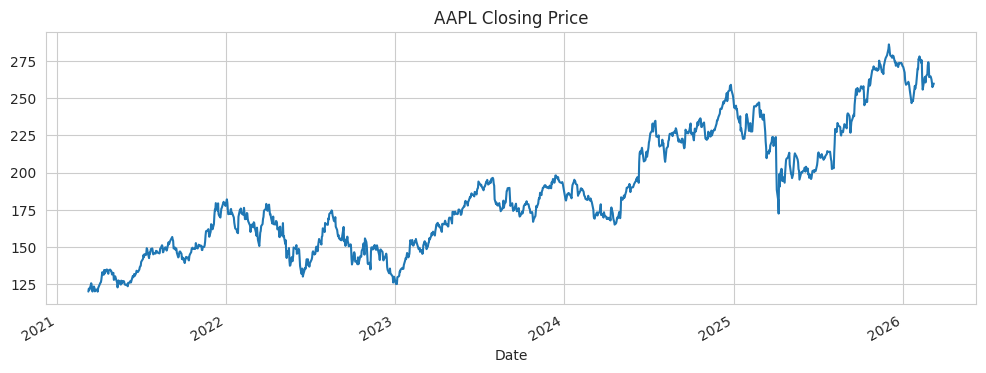

In [ ]:
# PREVIEW DOWNLOADED DATA
# Purpose: Display sample data to verify successful download (handles multi-level columns)

if FOCUS_STOCK not in stock_data:
    print(f"❌ ERROR: {FOCUS_STOCK} not found in downloaded data!")
    print(f"Available stocks: {list(stock_data.keys())}")
else:
    print(f"📊 SAMPLE DATA FOR {FOCUS_STOCK}")
    print("=" * 60)

    # Get the dataframe for the focus stock
    focus_df = stock_data[FOCUS_STOCK]

    # Flatten multi-level columns if needed
    if isinstance(focus_df.columns, pd.MultiIndex):
        focus_df.columns = ['_'.join(col).strip() for col in focus_df.columns.values]

    # Display first 10 rows
    print("\n📋 First 10 rows:")
    display(focus_df.head(10))

    # Show data dimensions
    print(f"\n📈 DATA SUMMARY:")
    print(f"  Rows (trading days): {focus_df.shape[0]:,}")
    print(f"  Columns: {focus_df.shape[1]}")
    print(f"  Column names: {list(focus_df.columns)}")
    print(f"  Date range: {focus_df.index[0].date()} to {focus_df.index[-1].date()}")

    # Show basic stats (adjust column names after flattening)
    close_col = f"Close_{FOCUS_STOCK}"  # matches flattened column
    print(f"\n📊 BASIC STATS:")
    print(f"  Latest Close: ${focus_df[close_col].iloc[-1]:.2f}")
    print(f"  Average Close: ${focus_df[close_col].mean():.2f}")
    print(f"  Min Close: ${focus_df[close_col].min():.2f}")
    print(f"  Max Close: ${focus_df[close_col].max():.2f}")

    # Plot preview
    print(f"\n📈 Quick price preview:")
    focus_df[close_col].plot(figsize=(12, 4), title=f'{FOCUS_STOCK} Closing Price')

## SAVE RAW DATA TO GOOGLE DRIVE

**Purpose:** Save downloaded data as CSV files for backup and future use

**Files Created:**
- Individual CSV for each stock (e.g., AAPL_raw.csv)
- Combined CSV with all closing prices (all_stocks_combined.csv)

**Why save raw data?**
- Backup in case download fails later
- Can reload without re-downloading
- Faster to work with local files

**Location:** `/stock_market_analysis/data/raw/`

In [ ]:
# SAVE RAW DATA TO GOOGLE DRIVE
# Purpose: Save downloaded data as CSV files for backup (handles multi-level columns)

print("💾 Saving data to Google Drive...")
print("=" * 60)

# Save each stock as individual CSV file
for ticker, df in stock_data.items():
    # Flatten multi-level columns if needed
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = ['_'.join(col).strip() for col in df.columns.values]
    filepath = f'{base_path}/data/raw/{ticker}_raw.csv'
    df.to_csv(filepath)
    print(f"✓ Saved {ticker} → {ticker}_raw.csv")

# Create combined dataset with all closing prices
combined_close = pd.DataFrame()
for ticker, df in stock_data.items():
    # Determine correct Close column after flattening
    close_col = f"Close_{ticker}" if f"Close_{ticker}" in df.columns else "Close"
    combined_close[ticker] = df[close_col]

# Save combined dataset
combined_path = f'{base_path}/data/raw/all_stocks_combined.csv'
combined_close.to_csv(combined_path)
print(f"✓ Saved combined dataset → all_stocks_combined.csv")

print("=" * 60)
print("✓ All data saved successfully!")

💾 Saving data to Google Drive...
✓ Saved AAPL → AAPL_raw.csv
✓ Saved MSFT → MSFT_raw.csv
✓ Saved GOOGL → GOOGL_raw.csv
✓ Saved AMZN → AMZN_raw.csv
✓ Saved TSLA → TSLA_raw.csv
✓ Saved combined dataset → all_stocks_combined.csv
✓ All data saved successfully!


## VISUALIZE ALL STOCKS PERFORMANCE

**Purpose:** Create a comparative chart showing relative performance of all stocks

**Visualization Type:** Normalized line chart

**What is normalization?**
- Sets all stocks to start at 100
- Shows relative performance (% gain/loss)
- Makes comparison easier regardless of actual price

**Example:**
- Stock A: $10 → $20 = 100 → 200 (100% gain)
- Stock B: $100 → $150 = 100 → 150 (50% gain)

**Saved as:** `01_all_stocks.png`

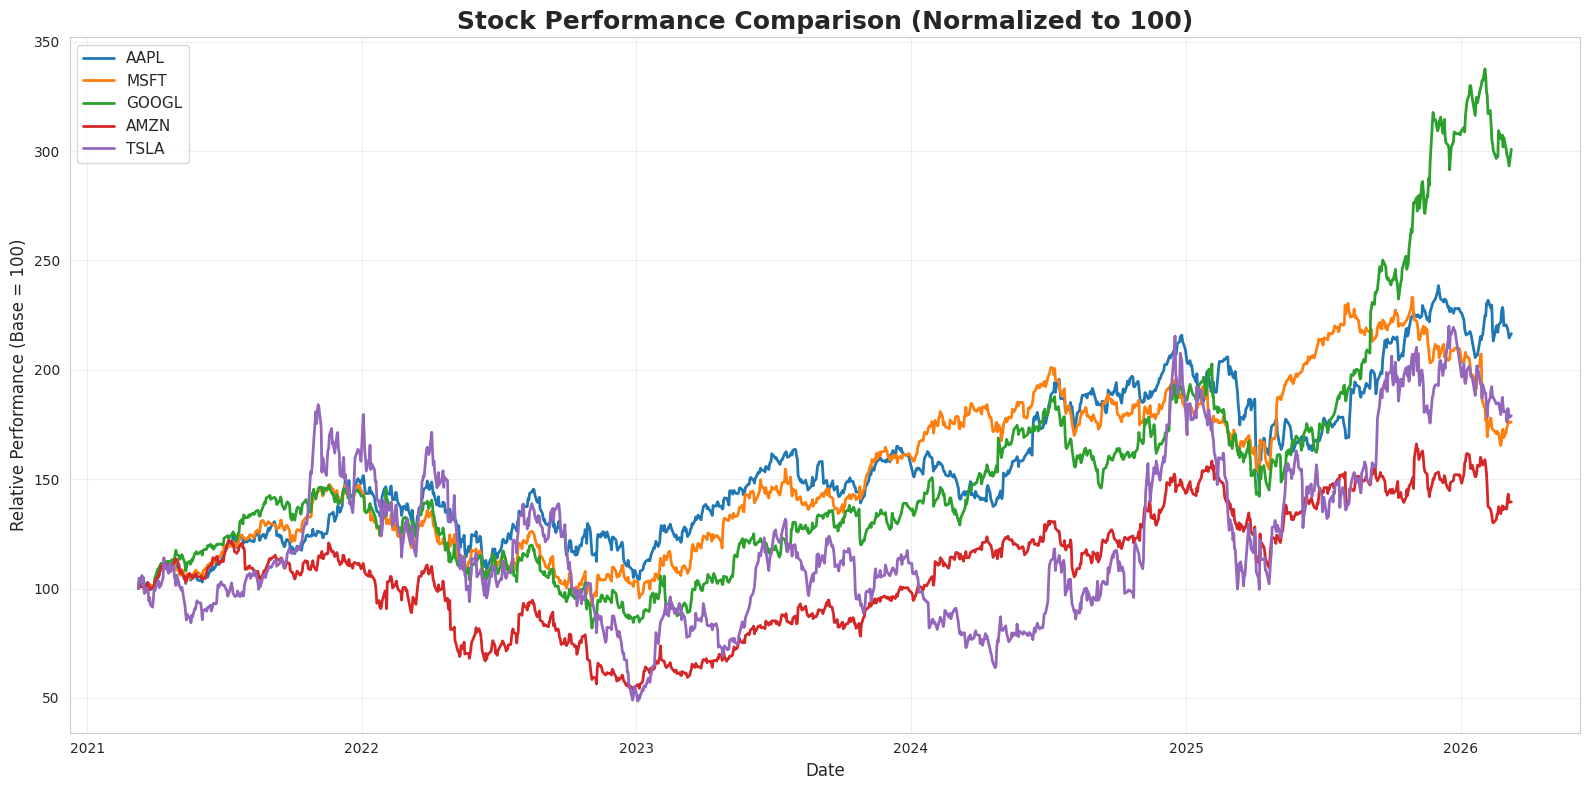

✓ Chart saved: 01_all_stocks.png


In [ ]:
# VISUALIZE ALL STOCKS PERFORMANCE
# Purpose: Create normalized comparison chart of all stocks

plt.figure(figsize=(16, 8))

for ticker, df in stock_data.items():
    # Flatten columns if multi-level
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = ['_'.join(col).strip() for col in df.columns.values]

    # Determine correct Close column
    close_col = f"Close_{ticker}" if f"Close_{ticker}" in df.columns else "Close"

    # Normalize and plot
    normalized = (df[close_col] / df[close_col].iloc[0]) * 100
    plt.plot(normalized, label=ticker, linewidth=2)

# Customize plot
plt.title('Stock Performance Comparison (Normalized to 100)',
          fontsize=18, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Relative Performance (Base = 100)', fontsize=12)
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save figure
save_path = f'{base_path}/outputs/figures/01_all_stocks.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Chart saved: 01_all_stocks.png")

LOAD FOCUS STOCK FOR ANALYSIS

Purpose: Select one stock for detailed feature engineering and ML modeling

Why focus on one stock?

Easier to demonstrate ML concepts

Faster training time

Same approach can be applied to other stocks

Focus Stock: Apple (AAPL)

Next Steps: Flatten columns if multi-level, then preview data

In [ ]:
# LOAD FOCUS STOCK FOR ANALYSIS
# Purpose: Select Apple (AAPL) for detailed ML analysis

# Flatten multi-level columns if needed
if isinstance(stock_data[FOCUS_STOCK].columns, pd.MultiIndex):
    stock_data[FOCUS_STOCK].columns = ['_'.join(col).strip() for col in stock_data[FOCUS_STOCK].columns.values]

# Rename for consistent column names
df = stock_data[FOCUS_STOCK].copy()
df.rename(columns={f'Close_{FOCUS_STOCK}': 'Close',
                   f'Open_{FOCUS_STOCK}': 'Open',
                   f'High_{FOCUS_STOCK}': 'High',
                   f'Low_{FOCUS_STOCK}': 'Low',
                   f'Adj Close_{FOCUS_STOCK}': 'Adj_Close',
                   f'Volume_{FOCUS_STOCK}': 'Volume'}, inplace=True)

# Preview
print(f"📊 LOADED: {FOCUS_STOCK}")
print("=" * 60)
print(f"Total rows: {df.shape[0]:,}")
print(f"Total columns: {df.shape[1]}")
print(f"Date range: {df.index[0].date()} to {df.index[-1].date()}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")

📊 LOADED: AAPL
Total rows: 1,255
Total columns: 6
Date range: 2021-03-10 to 2026-03-09
Memory usage: 68.63 KB


## DATA QUALITY CHECK

**Purpose:** Verify data quality before analysis

**Quality Checks:**
1. **Missing Values** - Check for gaps in data
2. **Duplicates** - Ensure no repeated dates
3. **Price Statistics** - Verify reasonable values
4. **Data Types** - Confirm numeric columns

**Expected Result:** Clean data with no issues

**What if there are issues?**
- Missing values: Will be handled in feature engineering
- Duplicates: Would be removed
- Invalid prices: Would indicate data problem

In [ ]:
# DATA QUALITY CHECK
# Purpose: Verify data quality and identify potential issues

print("🔍 DATA QUALITY REPORT")
print("=" * 60)

# 1. Missing values
missing_count = df.isnull().sum().sum()
print(f"\n1. Missing Values: {missing_count}")
if missing_count == 0:
    print("   ✓ No missing values detected")
else:
    print(f"   ⚠ Found {missing_count} missing values")
    print(df.isnull().sum())

# 2. Duplicates
duplicate_count = df.duplicated().sum()
print(f"\n2. Duplicate Rows: {duplicate_count}")
if duplicate_count == 0:
    print("   ✓ No duplicates detected")

# 3. Price statistics
print(f"\n3. Price Statistics (USD):")
print(f"   Mean Close: ${df['Close'].mean():.2f}")
print(f"   Std Dev: ${df['Close'].std():.2f}")
print(f"   Min Price: ${df['Close'].min():.2f}")
print(f"   Max Price: ${df['Close'].max():.2f}")
print(f"   Latest Price: ${df['Close'].iloc[-1]:.2f}")

# 4. Data types
print(f"\n4. Data Types:")
print(df.dtypes)

print("=" * 60)
print("✓ Data quality check complete!")

🔍 DATA QUALITY REPORT

1. Missing Values: 0
   ✓ No missing values detected

2. Duplicate Rows: 0
   ✓ No duplicates detected

3. Price Statistics (USD):
   Mean Close: $186.26
   Std Dev: $40.79
   Min Price: $119.90
   Max Price: $286.19
   Latest Price: $259.88

4. Data Types:
Adj_Close    float64
Close        float64
High         float64
Low          float64
Open         float64
Volume         int64
dtype: object
✓ Data quality check complete!


## CREATE PRICE-BASED FEATURES

**Purpose:** Engineer features from price and volume data

**Features Created (11 total):**

**1. Returns:**
- Daily Return: % change from previous day
- Log Return: Logarithmic return (better for modeling)

**2. Price Metrics:**
- Price Change: Difference between Close and Open
- Price Range: Difference between High and Low

**3. Moving Averages (MA):**
- MA_5: 5-day average (short-term trend)
- MA_20: 20-day average (medium-term trend)
- MA_50: 50-day average (long-term trend)
- MA_200: 200-day average (very long-term trend)

**4. MA Signals:**
- MA_5_20_Diff: Short vs medium term
- MA_50_200_Diff: Golden cross / death cross indicator

**Why these features?** They capture different aspects of price behavior and trends

In [ ]:
# CREATE PRICE-BASED FEATURES
# Purpose: Engineer 11 features from price and volume data

# Create copy to preserve original data
df_features = df.copy()

print("🔧 Creating price-based features...")

# 1. RETURNS
df_features['Daily_Return'] = df_features['Close'].pct_change()
df_features['Log_Return'] = np.log(df_features['Close'] / df_features['Close'].shift(1))

# 2. PRICE METRICS
df_features['Price_Change'] = df_features['Close'] - df_features['Open']
df_features['Price_Range'] = df_features['High'] - df_features['Low']

# 3. MOVING AVERAGES
df_features['MA_5'] = df_features['Close'].rolling(window=5).mean()
df_features['MA_20'] = df_features['Close'].rolling(window=20).mean()
df_features['MA_50'] = df_features['Close'].rolling(window=50).mean()
df_features['MA_200'] = df_features['Close'].rolling(window=200).mean()

# 4. MA CROSSOVER SIGNALS
df_features['MA_5_20_Diff'] = df_features['MA_5'] - df_features['MA_20']
df_features['MA_50_200_Diff'] = df_features['MA_50'] - df_features['MA_200']

print(f"✓ Created 11 price-based features")
print(f"   New shape: {df_features.shape}")

🔧 Creating price-based features...
✓ Created 11 price-based features
   New shape: (1255, 16)


## CREATE TECHNICAL INDICATORS

**Purpose:** Add advanced technical analysis indicators

**Indicators Created (12 total):**

**1. RSI (Relative Strength Index)**
- Measures overbought/oversold conditions
- Range: 0-100
- >70 = Overbought, <30 = Oversold

**2. MACD (Moving Average Convergence Divergence)**
- MACD Line: Difference between 12 & 26 day EMAs
- Signal Line: 9-day EMA of MACD
- Histogram: Difference between MACD and Signal

**3. Bollinger Bands**
- Upper Band: MA + 2 standard deviations
- Middle Band: 20-day MA
- Lower Band: MA - 2 standard deviations
- Width: Distance between upper and lower

**4. ATR (Average True Range)**
- Measures volatility
- Higher = More volatile

**5. OBV (On-Balance Volume)**
- Relates volume to price changes
- Confirms trends

**6. Stochastic Oscillator**
- K Line: Current momentum
- D Line: 3-day MA of K
- Range: 0-100

**Why these?** Professional traders use these indicators for decision-making

In [ ]:
# CREATE TECHNICAL INDICATORS
# Purpose: Add 12 professional technical analysis indicators

import pandas_ta as ta

print("📊 Creating technical indicators...")

# 1. RSI - Relative Strength Index
df_features['RSI'] = ta.rsi(df_features['Close'], length=14)

# 2. MACD - Moving Average Convergence Divergence
macd_result = ta.macd(df_features['Close'])
if macd_result is not None and len(macd_result.columns) >= 3:
    df_features['MACD'] = macd_result.iloc[:, 0]          # MACD line
    df_features['MACD_Signal'] = macd_result.iloc[:, 1]   # Signal line
    df_features['MACD_Hist'] = macd_result.iloc[:, 2]     # Histogram

# 3. BOLLINGER BANDS
bb_result = ta.bbands(df_features['Close'], length=20)
if bb_result is not None and len(bb_result.columns) >= 3:
    df_features['BB_Lower'] = bb_result.iloc[:, 0]   # Lower band
    df_features['BB_Middle'] = bb_result.iloc[:, 1]  # Middle band (SMA)
    df_features['BB_Upper'] = bb_result.iloc[:, 2]   # Upper band
    df_features['BB_Width'] = df_features['BB_Upper'] - df_features['BB_Lower']

# 4. ATR - Average True Range (Volatility)
df_features['ATR'] = ta.atr(df_features['High'], df_features['Low'],
                             df_features['Close'], length=14)

# 5. OBV - On-Balance Volume
df_features['OBV'] = ta.obv(df_features['Close'], df_features['Volume'])

# 6. STOCHASTIC OSCILLATOR
stoch_result = ta.stoch(df_features['High'], df_features['Low'], df_features['Close'])
if stoch_result is not None and len(stoch_result.columns) >= 2:
    df_features['Stoch_K'] = stoch_result.iloc[:, 0]  # %K line
    df_features['Stoch_D'] = stoch_result.iloc[:, 1]  # %D line

print(f"✓ Created 12 technical indicators")
print(f"   Current shape: {df_features.shape}")

📊 Creating technical indicators...
✓ Created 12 technical indicators
   Current shape: (1255, 28)


## CREATE LAG FEATURES

**Purpose:** Add historical values as features

**Lag Features (10 total):**

**What is a lag feature?**
- Value from N days ago
- Example: Close_Lag_1 = Yesterday's closing price

**Lags Created:**
- Lag 1: Yesterday's values
- Lag 2: 2 days ago
- Lag 3: 3 days ago
- Lag 5: 1 week ago
- Lag 10: 2 weeks ago

**For both:**
- Close price
- Volume

**Why use lags?**
- Recent history often predicts future
- ML models can find patterns in sequences
- Captures momentum and trends

**Example Use:**
If price has been rising for 5 days, it might continue or reverse

In [ ]:
# CREATE LAG FEATURES
# Purpose: Add historical prices and volumes as features

print("⏮ Creating lag features...")

# Create lags for different time periods
lag_periods = [1, 2, 3, 5, 10]

for lag in lag_periods:
    # Lag for closing price
    df_features[f'Close_Lag_{lag}'] = df_features['Close'].shift(lag)

    # Lag for volume
    df_features[f'Volume_Lag_{lag}'] = df_features['Volume'].shift(lag)

    print(f"   ✓ Created lag {lag} features")

print(f"\n✓ Created 10 lag features (5 for price, 5 for volume)")
print(f"   Total features now: {df_features.shape[1]}")

⏮ Creating lag features...
   ✓ Created lag 1 features
   ✓ Created lag 2 features
   ✓ Created lag 3 features
   ✓ Created lag 5 features
   ✓ Created lag 10 features

✓ Created 10 lag features (5 for price, 5 for volume)
   Total features now: 38


## CREATE TARGET VARIABLE

**Purpose:** Define what we want to predict

**Targets Created:**

**1. Target (Primary)**
- Next day's closing price
- Regression problem
- Example: Predict $150.25

**2. Target_Direction**
- Will price go up or down?
- Binary classification (0 or 1)
- 1 = Up, 0 = Down

**3. Target_Return**
- Percentage change
- Example: +2.5% or -1.3%

**For this project:** We'll use Target (price prediction)

**Why shift(-1)?**
- shift(-1) moves data one row up
- Creates "future" value
- Row's features predict next row's price

In [ ]:
# CREATE TARGET VARIABLE
# Purpose: Define what we want to predict (next day's price)

print("🎯 Creating target variables...")

# PRIMARY TARGET: Next day's closing price
df_features['Target'] = df_features['Close'].shift(-1)

# ALTERNATIVE TARGET 1: Direction (up=1, down=0)
df_features['Target_Direction'] = (df_features['Target'] > df_features['Close']).astype(int)

# ALTERNATIVE TARGET 2: Percentage return
df_features['Target_Return'] = ((df_features['Target'] - df_features['Close']) /
                                 df_features['Close']) * 100

print("✓ Created 3 target variables:")
print("   1. Target: Next day's price (regression)")
print("   2. Target_Direction: Up/Down (classification)")
print("   3. Target_Return: Percentage change")
print(f"\nExample from latest data:")
print(f"   Today's Close: ${df_features['Close'].iloc[-10]:.2f}")
print(f"   Target (Tomorrow): ${df_features['Target'].iloc[-10]:.2f}")
print(f"   Direction: {'Up' if df_features['Target_Direction'].iloc[-10] == 1 else 'Down'}")

🎯 Creating target variables...
✓ Created 3 target variables:
   1. Target: Next day's price (regression)
   2. Target_Direction: Up/Down (classification)
   3. Target_Return: Percentage change

Example from latest data:
   Today's Close: $272.14
   Target (Tomorrow): $274.23
   Direction: Up


## CLEAN MISSING VALUES

**Purpose:** Remove rows with missing data

**Why are there missing values?**
- Moving averages need X days to calculate
- MA_200 needs 200 days of data
- Lag features create NaN for first rows
- shift(-1) creates NaN for last row

**Cleaning Strategy:**
- Drop all rows with any NaN value
- Ensures clean dataset for ML models

**Trade-off:**
- Lose ~200 rows at beginning (MA_200)
- Lose 1 row at end (shift)
- Still have 1000+ rows remaining

**Result:** Complete dataset ready for modeling

In [ ]:
# CLEAN MISSING VALUES
# Purpose: Remove rows with NaN values created by features

print("🧹 Cleaning missing values...")
print("=" * 60)

# Count missing values before cleaning
missing_before = df_features.isnull().sum().sum()
rows_before = len(df_features)

print(f"Before cleaning:")
print(f"   Total rows: {rows_before:,}")
print(f"   Missing values: {missing_before:,}")

# Remove rows with any missing values
df_features = df_features.dropna()

# Count after cleaning
missing_after = df_features.isnull().sum().sum()
rows_after = len(df_features)
rows_removed = rows_before - rows_after

print(f"\nAfter cleaning:")
print(f"   Total rows: {rows_after:,}")
print(f"   Missing values: {missing_after}")
print(f"   Rows removed: {rows_removed:,}")

print("=" * 60)
print(f"✓ Final dataset shape: {df_features.shape}")
print(f"   Rows: {df_features.shape[0]:,}")
print(f"   Features: {df_features.shape[1]}")

🧹 Cleaning missing values...
Before cleaning:
   Total rows: 1,255
   Missing values: 749

After cleaning:
   Total rows: 1,055
   Missing values: 0
   Rows removed: 200
✓ Final dataset shape: (1055, 41)
   Rows: 1,055
   Features: 41


## SAVE PROCESSED DATA

**Purpose:** Save cleaned dataset with all features

**What's Saved:**
- All 40+ features
- Target variables
- Date index preserved

**File:** `AAPL_processed.csv`

**Location:** `/data/processed/`

**Why save?**
- Can reload without re-running all cells
- Backup of processed data
- Can share processed data with others

**File Size:** Approximately 1-2 MB

In [ ]:
# SAVE PROCESSED DATA
# Purpose: Save cleaned dataset with all engineered features

# Define output path
output_path = f'{base_path}/data/processed/{FOCUS_STOCK}_processed.csv'

# Save to CSV
df_features.to_csv(output_path)

print("💾 PROCESSED DATA SAVED")
print("=" * 60)
print(f"File: {FOCUS_STOCK}_processed.csv")
print(f"Location: {output_path}")
print(f"Size: {df_features.memory_usage(deep=True).sum() / 1024:.2f} KB")
print(f"Shape: {df_features.shape}")
print("=" * 60)
print("✓ Data ready for analysis and modeling!")

💾 PROCESSED DATA SAVED
File: AAPL_processed.csv
Location: /content/drive/MyDrive/stock_market_analysis/data/processed/AAPL_processed.csv
Size: 346.17 KB
Shape: (1055, 41)
✓ Data ready for analysis and modeling!


## PRICE & VOLUME VISUALIZATION

**Purpose:** Create professional chart showing price action and volume

**Chart Type:** Dual-axis chart (2 subplots)

**Top Panel - Price:**
- Blue line: Daily closing price
- Orange line: 20-day moving average (short-term trend)
- Green line: 50-day moving average (long-term trend)

**Bottom Panel - Volume:**
- Green bars: Days when price closed higher than it opened (bullish)
- Red bars: Days when price closed lower than it opened (bearish)

**What to look for:**
- Trend direction (up/down)
- MA crossovers (trend changes)
- Volume spikes (high interest/activity)

**Saved as:** `02_price_volume.png`

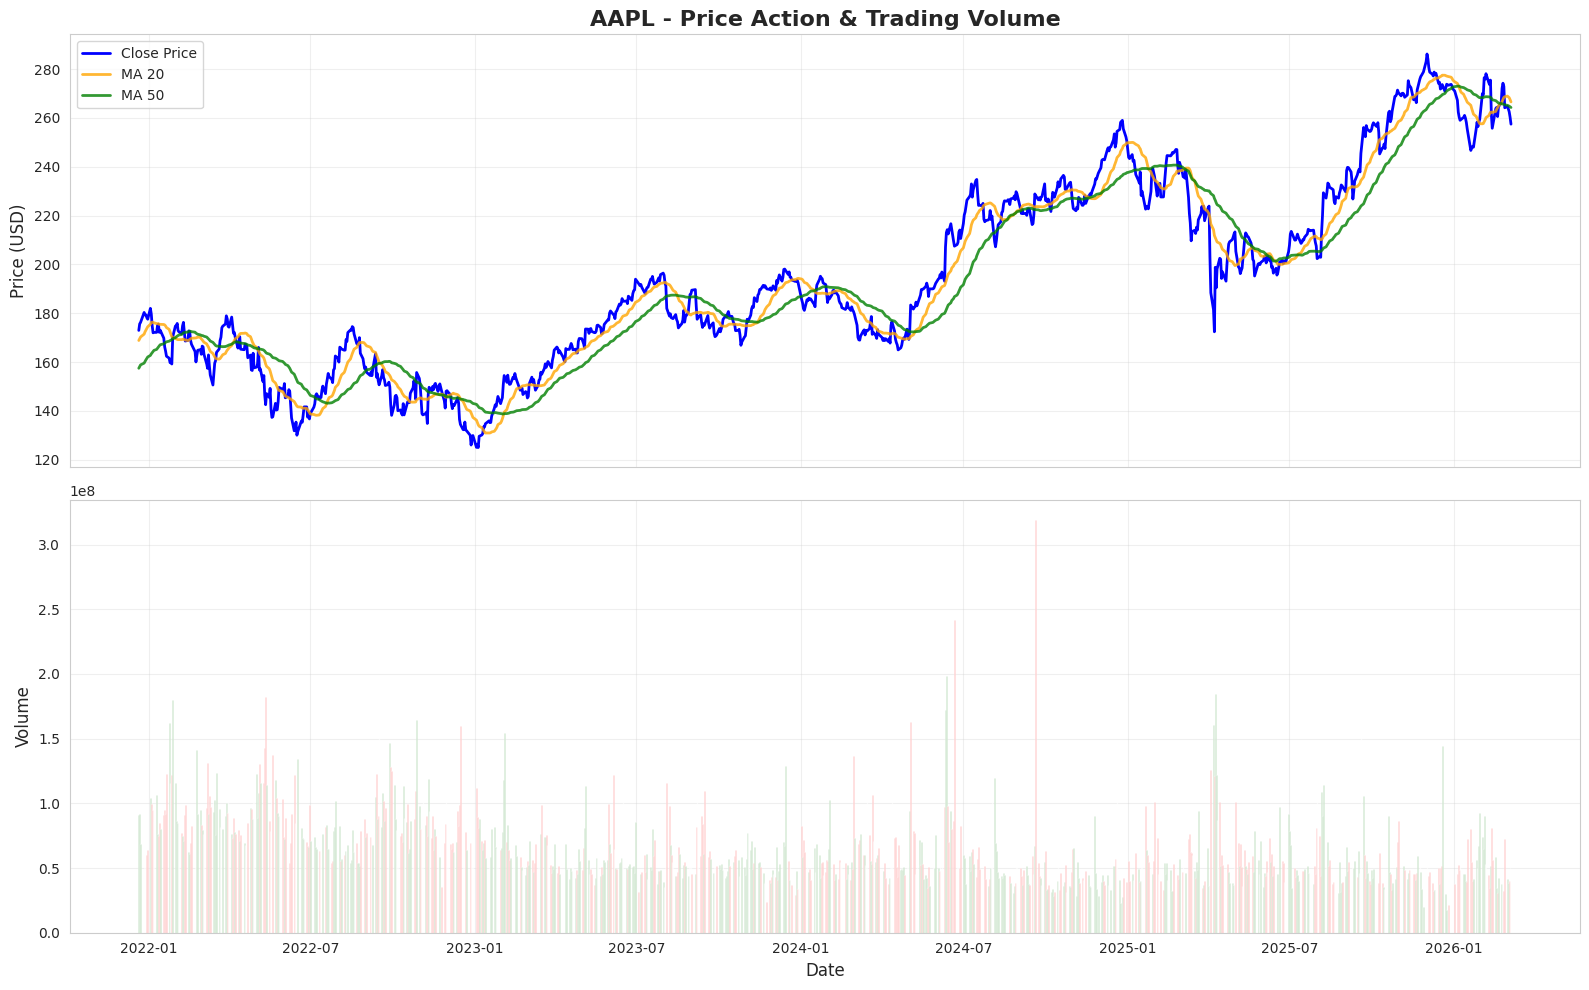

✓ Chart saved: 02_price_volume.png


In [ ]:
# PRICE & VOLUME VISUALIZATION
# Purpose: Create dual-panel chart showing price and volume trends

# Create figure with 2 subplots (sharing x-axis)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# TOP PANEL: Price with moving averages
ax1.plot(df_features.index, df_features['Close'],
         linewidth=2, color='blue', label='Close Price')
ax1.plot(df_features.index, df_features['MA_20'],
         linewidth=2, color='orange', label='MA 20', alpha=0.8)
ax1.plot(df_features.index, df_features['MA_50'],
         linewidth=2, color='green', label='MA 50', alpha=0.8)
ax1.set_ylabel('Price (USD)', fontsize=12)
ax1.set_title(f'{FOCUS_STOCK} - Price Action & Trading Volume',
              fontsize=16, fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# BOTTOM PANEL: Volume with color coding
# Green = bullish day (close > open), Red = bearish day (close < open)
colors = ['green' if df_features['Close'].iloc[i] > df_features['Open'].iloc[i]
          else 'red' for i in range(len(df_features))]
ax2.bar(df_features.index, df_features['Volume'], color=colors, alpha=0.6)
ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('Volume', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()

# Save figure
save_path = f'{base_path}/outputs/figures/02_price_volume.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print("✓ Chart saved: 02_price_volume.png")

## RETURNS ANALYSIS

**Purpose:** Analyze profitability and risk metrics

**4 Charts Created:**

**1. Daily Returns Distribution (Top Left)**
- Histogram showing frequency of daily % changes
- Red line: Average daily return
- Tells us: How spread out are the returns?

**2. Cumulative Returns (Top Right)**
- Shows total growth over time
- $100 invested at start would be worth how much?
- Green area shows profit accumulation

**3. Rolling Volatility (Bottom Left)**
- 30-day volatility (annualized %)
- Red = High risk period, Low = Stable period
- Helps identify risky times

**4. Yearly Returns (Bottom Right)**
- Total return for each year
- Green bars = Profitable year
- Red bars = Loss year

**Key Metrics Calculated:**
- Sharpe Ratio: Risk-adjusted returns (higher = better)
- Annualized Return: Average yearly gain/loss
- Volatility: How much price swings

**Saved as:** `03_returns.png`

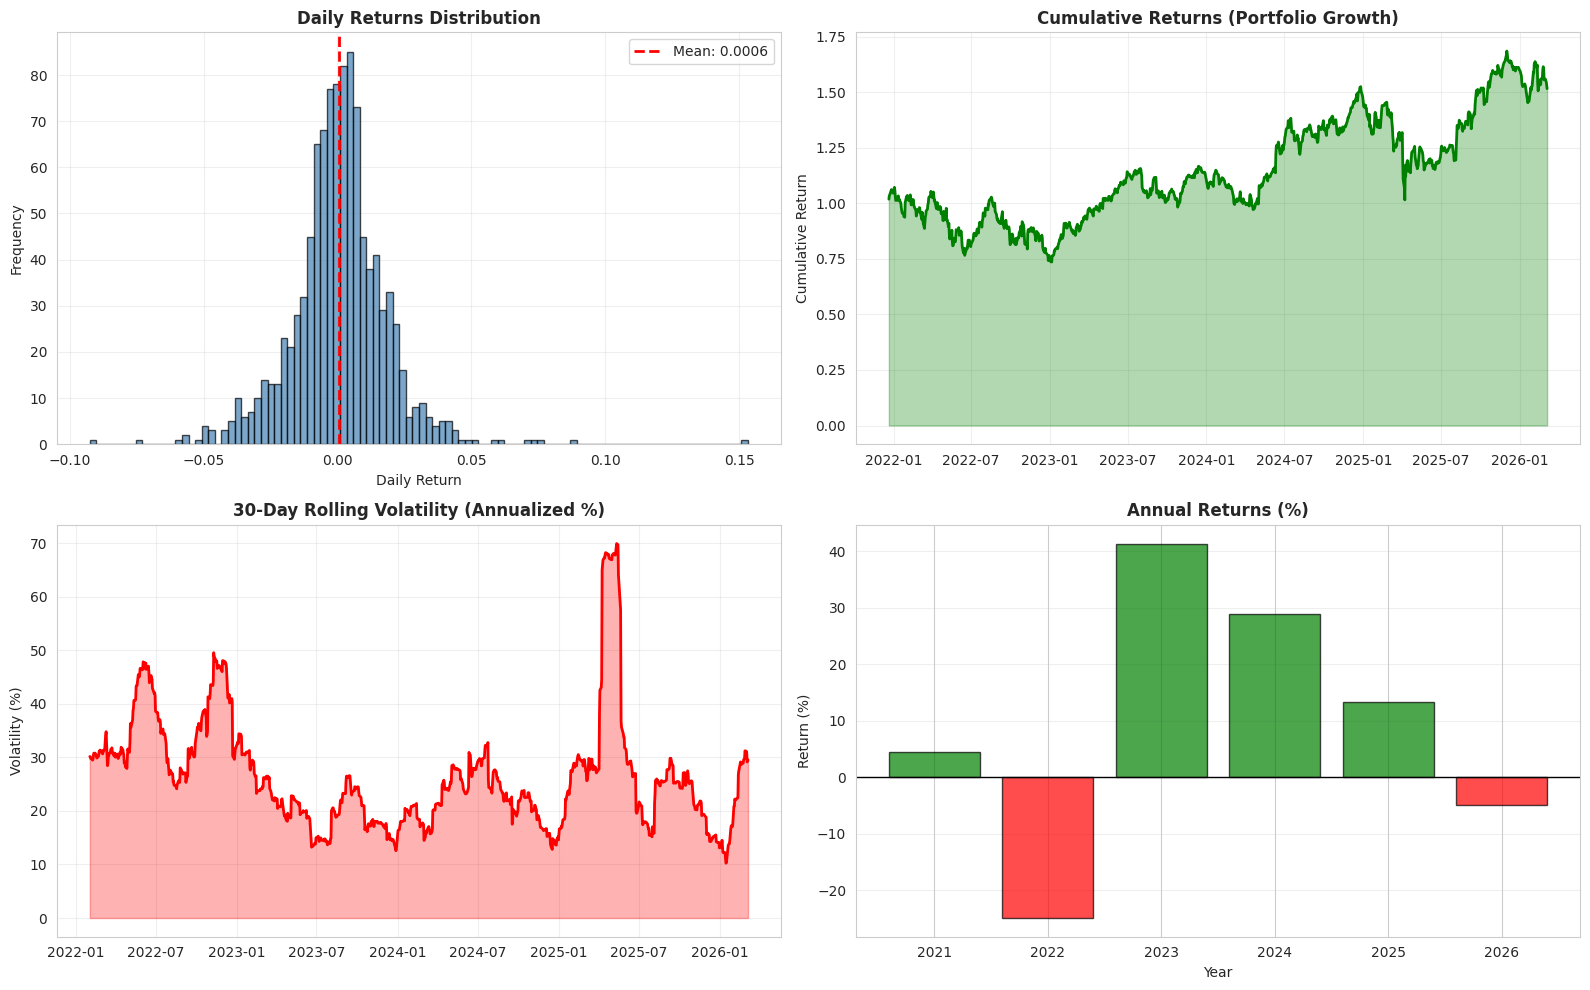


📊 RETURNS STATISTICS
Mean Daily Return: 0.06%
Daily Volatility: 1.79%
Annualized Return: 13.95%
Annualized Volatility: 28.38%
Sharpe Ratio: 0.49
Best Day: +15.33%
Worst Day: -9.25%


In [ ]:
# RETURNS ANALYSIS
# Purpose: Analyze profitability, risk, and return patterns

# Create 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. DAILY RETURNS DISTRIBUTION
axes[0, 0].hist(df_features['Daily_Return'].dropna(), bins=100,
                edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].axvline(df_features['Daily_Return'].mean(), color='red',
                   linestyle='--', linewidth=2,
                   label=f'Mean: {df_features["Daily_Return"].mean():.4f}')
axes[0, 0].set_title('Daily Returns Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Daily Return')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. CUMULATIVE RETURNS
cumulative = (1 + df_features['Daily_Return']).cumprod()
axes[0, 1].plot(df_features.index, cumulative, linewidth=2, color='green')
axes[0, 1].fill_between(df_features.index, cumulative, alpha=0.3, color='green')
axes[0, 1].set_title('Cumulative Returns (Portfolio Growth)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Cumulative Return')
axes[0, 1].grid(True, alpha=0.3)

# 3. ROLLING VOLATILITY (30-day)
rolling_vol = df_features['Daily_Return'].rolling(window=30).std() * np.sqrt(252) * 100
axes[1, 0].plot(df_features.index, rolling_vol, linewidth=2, color='red')
axes[1, 0].fill_between(df_features.index, rolling_vol, alpha=0.3, color='red')
axes[1, 0].set_title('30-Day Rolling Volatility (Annualized %)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Volatility (%)')
axes[1, 0].grid(True, alpha=0.3)

# 4. YEARLY RETURNS
df_features['Year'] = df_features.index.year
yearly_returns = df_features.groupby('Year')['Daily_Return'].sum() * 100
colors_yearly = ['green' if x > 0 else 'red' for x in yearly_returns]
axes[1, 1].bar(yearly_returns.index, yearly_returns.values,
               color=colors_yearly, edgecolor='black', alpha=0.7)
axes[1, 1].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[1, 1].set_title('Annual Returns (%)', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Return (%)')
axes[1, 1].set_xlabel('Year')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()

# Save figure
save_path = f'{base_path}/outputs/figures/03_returns.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

# Calculate and display key statistics
print("\n📊 RETURNS STATISTICS")
print("=" * 60)
print(f"Mean Daily Return: {df_features['Daily_Return'].mean()*100:.2f}%")
print(f"Daily Volatility: {df_features['Daily_Return'].std()*100:.2f}%")
print(f"Annualized Return: {df_features['Daily_Return'].mean()*252*100:.2f}%")
print(f"Annualized Volatility: {df_features['Daily_Return'].std()*np.sqrt(252)*100:.2f}%")
print(f"Sharpe Ratio: {(df_features['Daily_Return'].mean() / df_features['Daily_Return'].std()) * np.sqrt(252):.2f}")
print(f"Best Day: +{df_features['Daily_Return'].max()*100:.2f}%")
print(f"Worst Day: {df_features['Daily_Return'].min()*100:.2f}%")
print("=" * 60)

## TECHNICAL INDICATORS VISUALIZATION

**Purpose:** Display key trading indicators used by professionals

**3 Panels Created:**

**1. Bollinger Bands (Top)**
- Blue line: Actual price
- Dotted lines: Upper & lower bands (±2 std dev)
- Gray shading: Normal price range
- **Trading Signal:**
  - Price near upper band = Potentially overbought
  - Price near lower band = Potentially oversold

**2. RSI - Relative Strength Index (Middle)**
- Purple line: RSI value (0-100)
- Red line at 70: Overbought threshold
- Green line at 30: Oversold threshold
- **Trading Signal:**
  - RSI > 70 = Overbought (might fall)
  - RSI < 30 = Oversold (might rise)

**3. MACD - Moving Average Convergence Divergence (Bottom)**
- Blue line: MACD line
- Orange line: Signal line
- Bars: Histogram (difference)
- **Trading Signal:**
  - MACD crosses above Signal = Bullish
  - MACD crosses below Signal = Bearish

**Saved as:** `04_indicators.png`

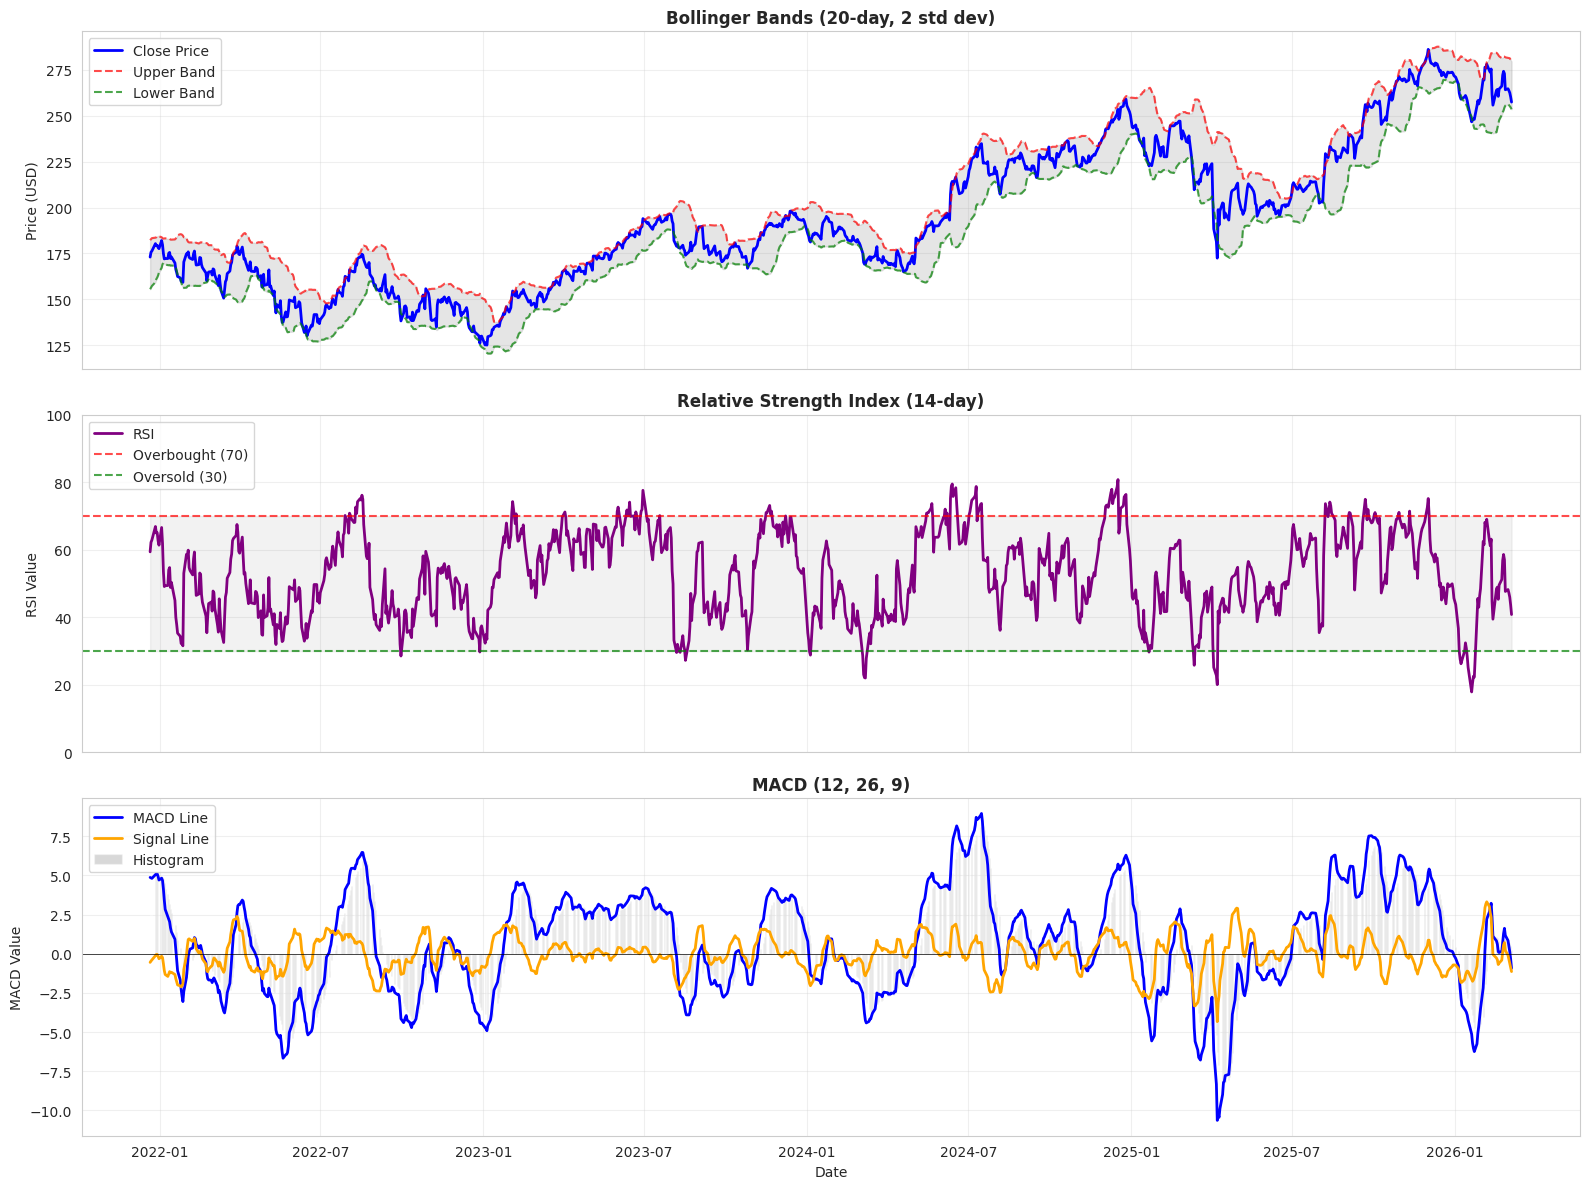

✓ Chart saved: 04_indicators.png


In [ ]:
# TECHNICAL INDICATORS VISUALIZATION
# Purpose: Display professional trading indicators

# Create 3-panel figure
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

# PANEL 1: BOLLINGER BANDS
axes[0].plot(df_features.index, df_features['Close'],
             label='Close Price', linewidth=2, color='blue')
axes[0].plot(df_features.index, df_features['BB_Upper'],
             label='Upper Band', linestyle='--', alpha=0.7, color='red')
axes[0].plot(df_features.index, df_features['BB_Lower'],
             label='Lower Band', linestyle='--', alpha=0.7, color='green')
axes[0].fill_between(df_features.index, df_features['BB_Upper'],
                     df_features['BB_Lower'], alpha=0.2, color='gray')
axes[0].set_ylabel('Price (USD)')
axes[0].set_title('Bollinger Bands (20-day, 2 std dev)',
                  fontsize=12, fontweight='bold')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

# PANEL 2: RSI
axes[1].plot(df_features.index, df_features['RSI'],
             linewidth=2, color='purple', label='RSI')
axes[1].axhline(y=70, color='r', linestyle='--', linewidth=1.5,
                label='Overbought (70)', alpha=0.7)
axes[1].axhline(y=30, color='g', linestyle='--', linewidth=1.5,
                label='Oversold (30)', alpha=0.7)
axes[1].fill_between(df_features.index, 30, 70, alpha=0.1, color='gray')
axes[1].set_ylabel('RSI Value')
axes[1].set_title('Relative Strength Index (14-day)',
                  fontsize=12, fontweight='bold')
axes[1].set_ylim(0, 100)
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)

# PANEL 3: MACD
axes[2].plot(df_features.index, df_features['MACD'],
             label='MACD Line', linewidth=2, color='blue')
axes[2].plot(df_features.index, df_features['MACD_Signal'],
             label='Signal Line', linewidth=2, color='orange')
axes[2].bar(df_features.index, df_features['MACD_Hist'],
            label='Histogram', alpha=0.3, color='gray')
axes[2].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[2].set_xlabel('Date')
axes[2].set_ylabel('MACD Value')
axes[2].set_title('MACD (12, 26, 9)', fontsize=12, fontweight='bold')
axes[2].legend(loc='upper left')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()

# Save figure
save_path = f'{base_path}/outputs/figures/04_indicators.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print("✓ Chart saved: 04_indicators.png")

## CORRELATION HEATMAP

**Purpose:** Identify which features are related to future returns

**What is Correlation?**
- Measures relationship between two variables
- Range: -1 to +1
- +1 = Perfect positive correlation (move together)
- -1 = Perfect negative correlation (move opposite)
- 0 = No correlation

**Color Coding:**
- Red: Positive correlation
- Blue: Negative correlation
- White: No correlation

**Key Features Analyzed:**
- Close, Volume, Daily_Return
- RSI, MACD, BB_Width
- ATR, Moving Averages
- Target_Return (what we predict)

**What to look for:**
- Strong correlations with Target_Return
- These are potentially good predictors

**Saved as:** `05_correlation.png`

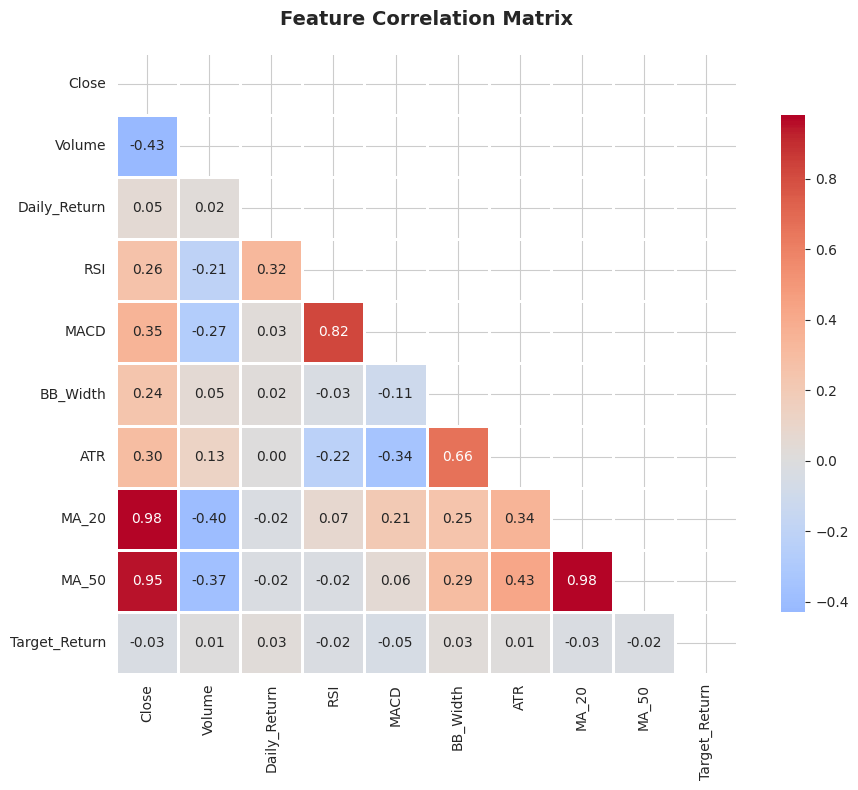


📊 TOP 5 CORRELATIONS WITH TARGET RETURN:
MACD                : -0.047 (negative)
Close               : -0.034 (negative)
BB_Width            : +0.033 (positive)
MA_20               : -0.025 (negative)
Daily_Return        : +0.025 (positive)


In [ ]:
# CORRELATION HEATMAP
# Purpose: Identify relationships between features and target

# Select key features for correlation analysis
key_features = ['Close', 'Volume', 'Daily_Return', 'RSI', 'MACD',
                'BB_Width', 'ATR', 'MA_20', 'MA_50', 'Target_Return']

# Calculate correlation matrix
correlation = df_features[key_features].corr()

# Create heatmap
plt.figure(figsize=(10, 8))

# Create mask for upper triangle (avoid duplicate information)
mask = np.triu(np.ones_like(correlation, dtype=bool))

# Plot heatmap
sns.heatmap(correlation, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True, linewidths=1,
            cbar_kws={"shrink": 0.8})

plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()

# Save figure
save_path = f'{base_path}/outputs/figures/05_correlation.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

# Display top correlations with target
print("\n📊 TOP 5 CORRELATIONS WITH TARGET RETURN:")
print("=" * 60)
target_corr = correlation['Target_Return'].abs().sort_values(ascending=False)[1:6]
for feature, corr_value in target_corr.items():
    actual_corr = correlation['Target_Return'][feature]
    direction = "positive" if actual_corr > 0 else "negative"
    print(f"{feature:20s}: {actual_corr:+.3f} ({direction})")
print("=" * 60)

In [ ]:
!pip install pandas numpy scikit-learn yfinance pandas-ta -q

In [ ]:
!pip install yfinance==0.2.40 -q

In [ ]:
import yfinance as yf
print("yfinance working ✅")

In [ ]:
# Fix binary incompatibility in Colab
!pip install --upgrade --quiet numpy scikit-learn

In [ ]:
!pip install numpy==1.25.2 scikit-learn==1.3.2 --quiet

In [ ]:
!pip uninstall -y numpy pandas scikit-learn

In [ ]:
!pip install numpy==1.25.2 pandas==2.2.2 scikit-learn==1.3.2

In [ ]:
# Uninstall just scikit-learn (if needed)
!pip uninstall -y scikit-learn

# Reinstall a version compatible with Colab's default numpy (usually numpy ~1.26.x)
!pip install scikit-learn==1.3.2 --upgrade

## PREPARE DATA FOR MACHINE LEARNING

**Purpose:** Split and scale data for ML models

**Process:**

**1. Feature Selection**
- Remove target columns (can't use future to predict future)
- Remove original OHLCV (redundant with features)
- Keep: All engineered features (40+)

**2. Train-Test Split**
- Train: First 80% of data (for learning)
- Test: Last 20% of data (for evaluation)
- **Important:** Time series split (not random)
  - Must maintain chronological order
  - Prevents data leakage (future info in training)

**3. Feature Scaling**
- StandardScaler: (value - mean) / std_dev
- Makes all features same scale
- Improves model performance

**Why scale?**
- Volume: millions
- Price: hundreds
- RSI: 0-100
- Different scales confuse ML models

**Result:** Clean X (features) and y (target) ready for training

In [ ]:
# PREPARE DATA FOR MACHINE LEARNING
# Purpose: Split data into train/test and scale features

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("🔧 Preparing data for ML models...")
print("=" * 60)

# 1. SELECT FEATURES
# Exclude targets and redundant columns
exclude = ['Target', 'Target_Direction', 'Target_Return',
           'Open', 'High', 'Low', 'Year']
feature_cols = [col for col in df_features.columns if col not in exclude]

# Create X (features) and y (target)
X = df_features[feature_cols].copy()
y = df_features['Target'].copy()

# Remove any remaining NaN
mask = ~(X.isna().any(axis=1) | y.isna())
X = X[mask]
y = y[mask]

print(f"Features selected: {len(feature_cols)}")
print(f"Total samples: {len(X):,}")

# 2. TRAIN-TEST SPLIT (80-20, chronological)
split_idx = int(len(X) * 0.8)
X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print(f"\nTrain-Test Split:")
print(f"  Training samples: {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Test samples: {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)")
print(f"  Train period: {X_train.index[0].date()} to {X_train.index[-1].date()}")
print(f"  Test period: {X_test.index[0].date()} to {X_test.index[-1].date()}")

# 3. SCALE FEATURES
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame (preserve column names)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print(f"\n✓ Features scaled using StandardScaler")
print("=" * 60)
print("✓ Data ready for model training!")

🔧 Preparing data for ML models...
Features selected: 35
Total samples: 1,055

Train-Test Split:
  Training samples: 844 (80.0%)
  Test samples: 211 (20.0%)
  Train period: 2021-12-21 to 2025-05-02
  Test period: 2025-05-05 to 2026-03-06

✓ Features scaled using StandardScaler
✓ Data ready for model training!


## TRAIN MACHINE LEARNING MODELS

**Purpose:** Train and evaluate multiple ML algorithms

**Models Trained (4 total):**

**1. Linear Regression**
- Simplest model
- Assumes linear relationship
- Fast to train
- Baseline for comparison

**2. Ridge Regression**
- Linear regression with regularization
- Prevents overfitting
- Handles multicollinearity

**3. Random Forest**
- Ensemble of decision trees
- Handles non-linear relationships
- Provides feature importance
- Usually best performer

**4. Gradient Boosting**
- Builds trees sequentially
- Corrects previous errors
- Very powerful
- Slower to train

**Evaluation Metrics:**
- **R² Score**: How much variance explained (0-1, higher better)
  - 0.90 = Model explains 90% of price movement
- **MAE**: Mean Absolute Error in dollars
  - $2.50 = Average prediction off by $2.50
- **MAPE**: Mean Absolute Percentage Error
  - 2% = Average 2% error

**Time:** 2-3 minutes to train all models

In [ ]:
# TRAIN MACHINE LEARNING MODELS
# Purpose: Train 4 different ML algorithms and compare performance

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("🤖 TRAINING MACHINE LEARNING MODELS")
print("=" * 60)
print("This may take 2-3 minutes...\n")

# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# Dictionary to store results
results = {}

# Train each model
for name, model in models.items():
    print(f"Training {name}...", end=" ")

    # Train model
    model.fit(X_train_scaled, y_train)

    # Make predictions
    y_pred = model.predict(X_test_scaled)

    # Calculate metrics
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

    # Store results
    results[name] = {
        'model': model,
        'r2': r2,
        'mae': mae,
        'rmse': rmse,
        'mape': mape,
        'predictions': y_pred
    }

    print(f"✓ R²={r2:.4f}, MAE=${mae:.2f}, MAPE={mape:.2f}%")

print("\n" + "=" * 60)
print("✓ All models trained successfully!")

🤖 TRAINING MACHINE LEARNING MODELS
This may take 2-3 minutes...

Training Linear Regression... ✓ R²=0.9842, MAE=$2.49, MAPE=1.04%
Training Ridge Regression... ✓ R²=0.9828, MAE=$2.55, MAPE=1.06%
Training Random Forest... ✓ R²=0.7120, MAE=$10.95, MAPE=4.19%
Training Gradient Boosting... ✓ R²=0.7317, MAE=$11.01, MAPE=4.23%

✓ All models trained successfully!


## COMPARE MODEL PERFORMANCE

**Purpose:** Visualize and compare all models

**Comparison Table Shows:**
- Model name
- R² Score (higher = better)
- MAE in dollars (lower = better)
- MAPE percentage (lower = better)

**Two Charts Created:**

**1. R² Score Comparison (Left)**
- Shows prediction accuracy
- Best model at top
- Aim for R² > 0.85 (85% variance explained)

**2. MAPE Comparison (Right)**
- Shows average error %
- Lower is better
- Aim for MAPE < 3%

**What Makes a Good Model?**
- R² > 0.85 (explains 85%+ of variance)
- MAE < $3 (predictions within $3)
- MAPE < 3% (less than 3% error)

**Expected:** Random Forest or Gradient Boosting usually wins

**Saved as:** `06_model_comparison.png`


📊 MODEL PERFORMANCE COMPARISON


,Model,R² Score,MAE (USD),RMSE (USD),MAPE (%)
0,Linear Regression,0.984207,2.494885,3.525703,1.039945
1,Ridge Regression,0.982787,2.551902,3.680755,1.061789
2,Gradient Boosting,0.731675,11.007093,14.532433,4.230176
3,Random Forest,0.712031,10.954347,15.054980,4.185028


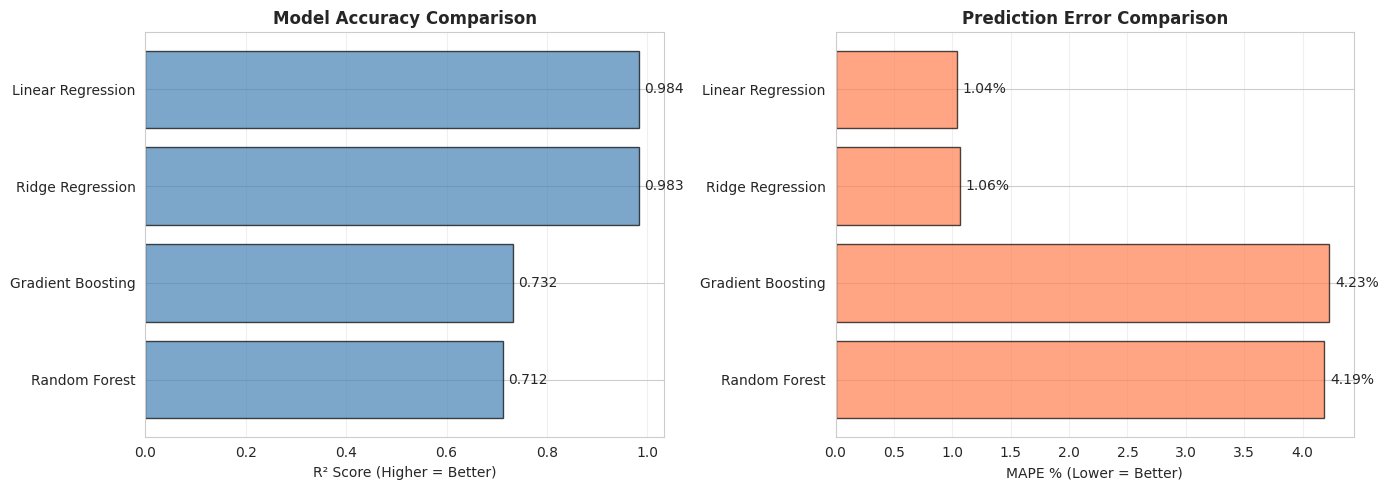


✓ Chart saved: 06_model_comparison.png


In [ ]:
# COMPARE MODEL PERFORMANCE
# Purpose: Create comparison table and visualization

# Create comparison dataframe
comparison = pd.DataFrame({
    'Model': list(results.keys()),
    'R² Score': [results[m]['r2'] for m in results.keys()],
    'MAE (USD)': [results[m]['mae'] for m in results.keys()],
    'RMSE (USD)': [results[m]['rmse'] for m in results.keys()],
    'MAPE (%)': [results[m]['mape'] for m in results.keys()]
})

# Sort by R² score (best first)
comparison = comparison.sort_values('R² Score', ascending=False).reset_index(drop=True)

# Display table
print("\n📊 MODEL PERFORMANCE COMPARISON")
print("=" * 80)
display(comparison)
print("=" * 80)

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: R² Score
x_pos = np.arange(len(comparison))
axes[0].barh(x_pos, comparison['R² Score'], alpha=0.7,
             color='steelblue', edgecolor='black')
axes[0].set_yticks(x_pos)
axes[0].set_yticklabels(comparison['Model'])
axes[0].set_xlabel('R² Score (Higher = Better)')
axes[0].set_title('Model Accuracy Comparison', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.3, axis='x')

# Add value labels
for i, v in enumerate(comparison['R² Score']):
    axes[0].text(v + 0.01, i, f'{v:.3f}', va='center')

# Chart 2: MAPE
axes[1].barh(x_pos, comparison['MAPE (%)'], alpha=0.7,
             color='coral', edgecolor='black')
axes[1].set_yticks(x_pos)
axes[1].set_yticklabels(comparison['Model'])
axes[1].set_xlabel('MAPE % (Lower = Better)')
axes[1].set_title('Prediction Error Comparison', fontsize=12, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(True, alpha=0.3, axis='x')

# Add value labels
for i, v in enumerate(comparison['MAPE (%)']):
    axes[1].text(v + 0.05, i, f'{v:.2f}%', va='center')

plt.tight_layout()

# Save figure
save_path = f'{base_path}/outputs/figures/06_model_comparison.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Chart saved: 06_model_comparison.png")

## BEST MODEL PREDICTIONS

**Purpose:** Visualize predictions from the best performing model

**Chart Shows:**
- Blue line: Actual prices (ground truth)
- Red dashed line: Model predictions
- Gray shading: Difference between actual and predicted

**What to look for:**
- Lines close together = Good predictions
- Lines diverging = Poor predictions
- Consistent gap = Systematic bias

**Performance Metrics Displayed:**
- R² Score: Overall accuracy
- MAE: Average dollar error
- MAPE: Average percentage error

**Interpretation Example:**
- R² = 0.92: Model explains 92% of price movement
- MAE = $2.15: Predictions off by $2.15 on average
- MAPE = 1.8%: Average error is 1.8%

**Saved as:** `07_predictions.png`


🏆 BEST MODEL: Linear Regression
R² Score: 0.9842
  → Explains 98.4% of price variance

MAE: $2.49
  → Predictions off by $2.49 on average

MAPE: 1.04%
  → Average percentage error is 1.04%


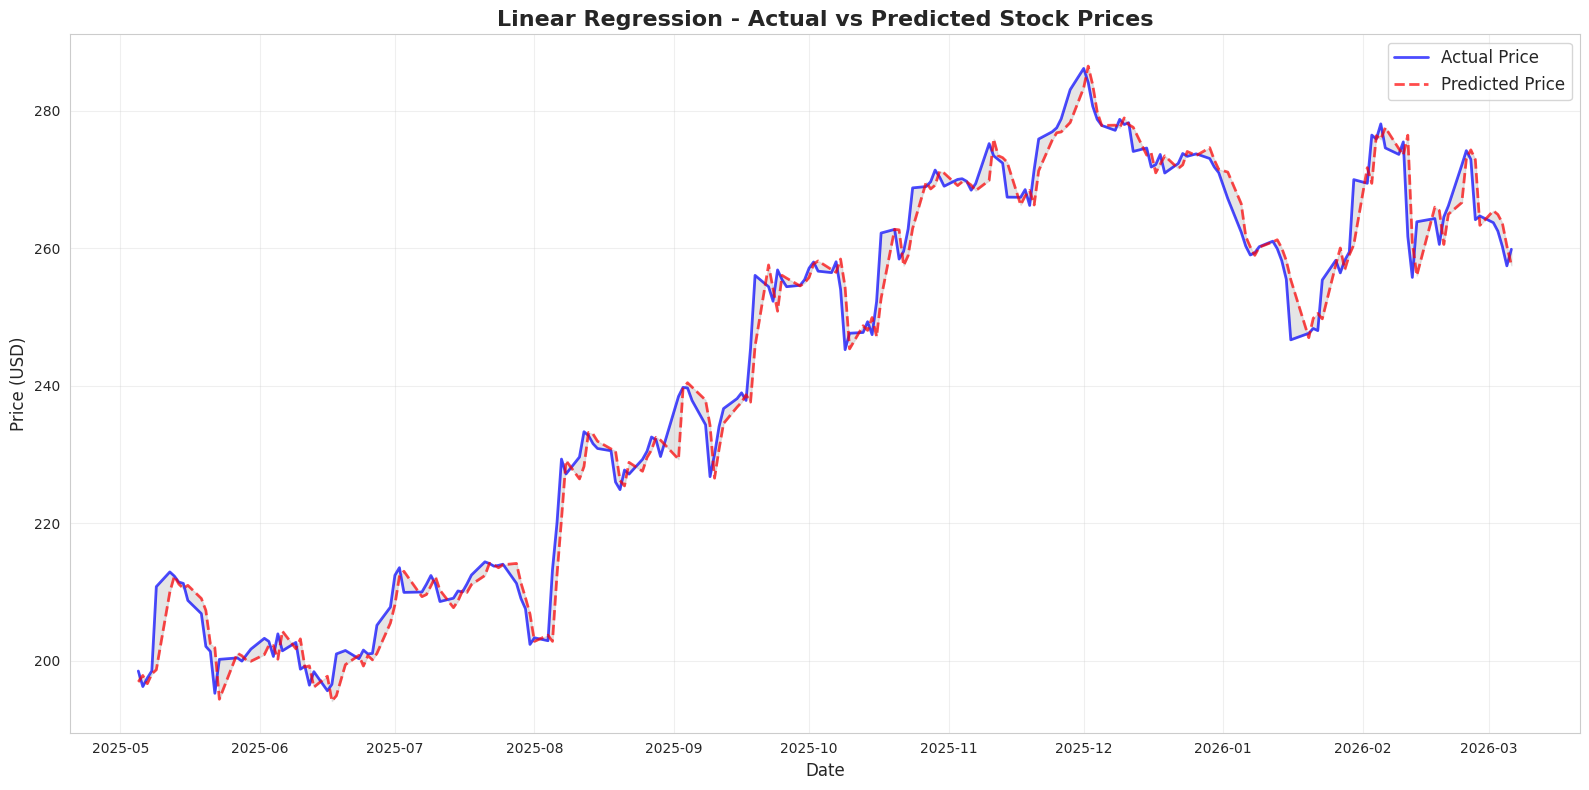


✓ Chart saved: 07_predictions.png


In [ ]:
# BEST MODEL PREDICTIONS
# Purpose: Visualize predictions from top-performing model

# Get best model
best_name = comparison.iloc[0]['Model']
best_model = results[best_name]['model']
y_pred_best = results[best_name]['predictions']

# Display metrics
print(f"\n🏆 BEST MODEL: {best_name}")
print("=" * 60)
print(f"R² Score: {results[best_name]['r2']:.4f}")
print(f"  → Explains {results[best_name]['r2']*100:.1f}% of price variance")
print(f"\nMAE: ${results[best_name]['mae']:.2f}")
print(f"  → Predictions off by ${results[best_name]['mae']:.2f} on average")
print(f"\nMAPE: {results[best_name]['mape']:.2f}%")
print(f"  → Average percentage error is {results[best_name]['mape']:.2f}%")
print("=" * 60)

# Create prediction plot
plt.figure(figsize=(16, 8))

# Plot actual prices
plt.plot(X_test.index, y_test.values,
         label='Actual Price', linewidth=2, color='blue', alpha=0.7)

# Plot predictions
plt.plot(X_test.index, y_pred_best,
         label='Predicted Price', linewidth=2, color='red',
         linestyle='--', alpha=0.7)

# Fill area between (shows error magnitude)
plt.fill_between(X_test.index, y_test.values, y_pred_best,
                 alpha=0.2, color='gray')

# Customize plot
plt.title(f'{best_name} - Actual vs Predicted Stock Prices',
          fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(fontsize=12, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save figure
save_path = f'{base_path}/outputs/figures/07_predictions.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Chart saved: 07_predictions.png")

## ERROR ANALYSIS

**Purpose:** Deep dive into prediction errors

**4 Charts Created:**

**1. Error Distribution (Top Left)**
- Histogram of prediction errors
- Red line: Average error
- Ideally centered at 0 (no bias)
- Narrow distribution = Consistent predictions

**2. Error Over Time (Top Right)**
- How errors change across time
- Helps identify if model worse in certain periods
- Should fluctuate randomly around 0

**3. Actual vs Predicted Scatter (Bottom Left)**
- Each dot = One prediction
- Red diagonal line = Perfect predictions
- Points close to line = Good predictions
- Pattern away from line = Systematic error

**4. Percentage Error (Bottom Right)**
- Error as % of actual price
- More meaningful than dollar error
- Shows if model struggles with high/low prices

**What Good Errors Look Like:**
- Centered at zero (no bias)
- Normally distributed (bell curve)
- Consistent across time
- No systematic patterns

**Saved as:** `08_error_analysis.png`

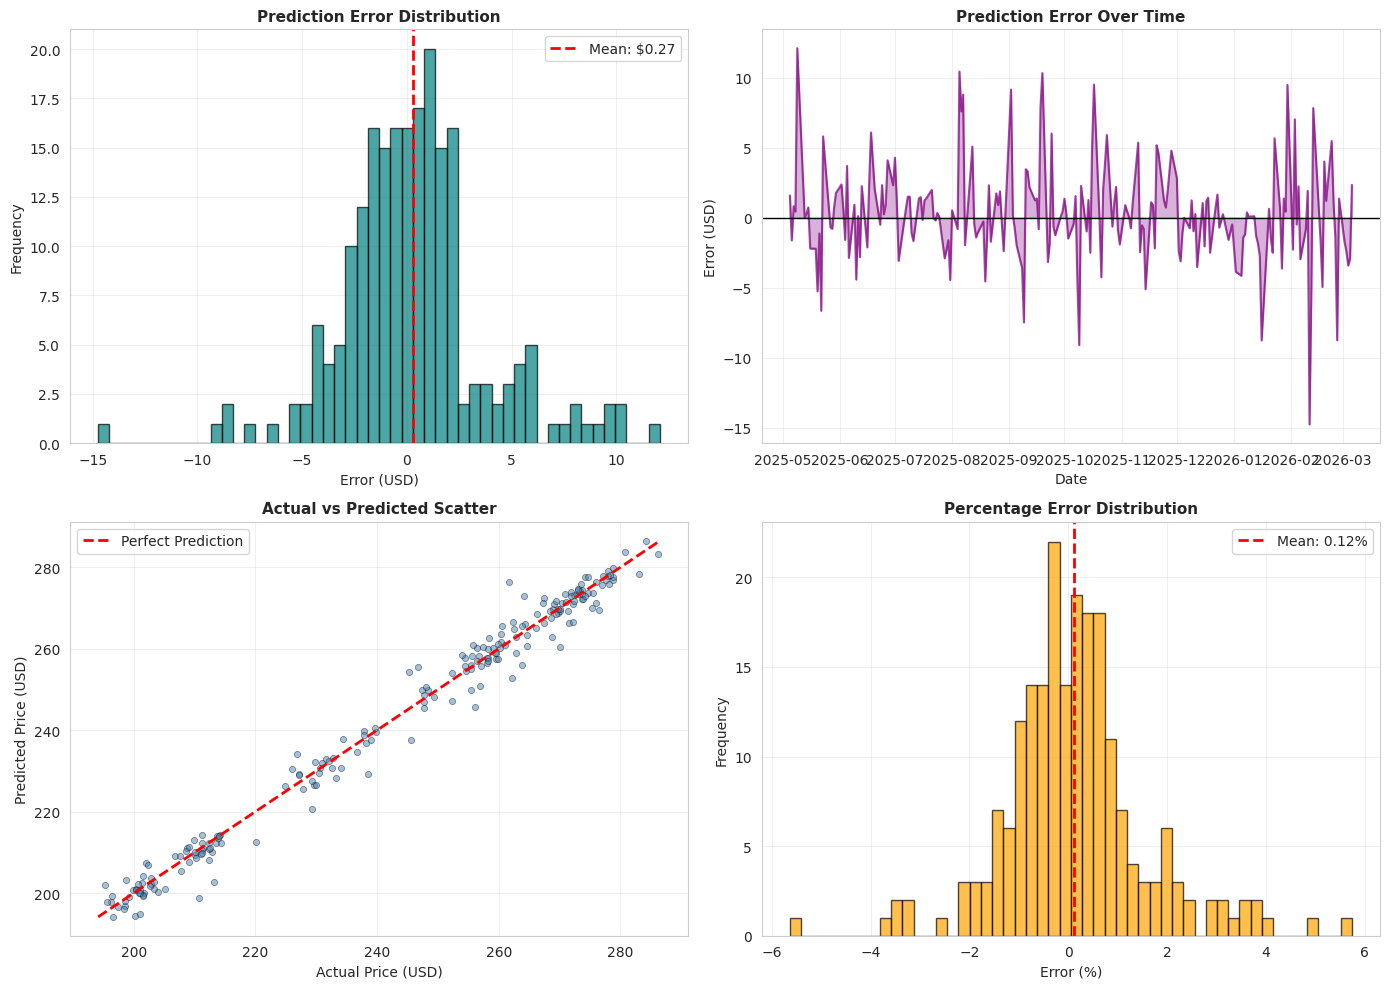


📊 ERROR ANALYSIS STATISTICS
Mean Error: $0.27
Std Dev: $3.52
Mean Absolute Error: $2.49
Mean % Error: 0.12%
Max Overestimate: $12.09
Max Underestimate: $-14.74

✓ Chart saved: 08_error_analysis.png


In [ ]:
# ERROR ANALYSIS
# Purpose: Analyze prediction errors in detail

# Calculate errors
errors = y_test.values - y_pred_best
error_pct = (errors / y_test.values) * 100

# Create 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. ERROR DISTRIBUTION
axes[0, 0].hist(errors, bins=50, edgecolor='black', alpha=0.7, color='teal')
axes[0, 0].axvline(errors.mean(), color='red', linestyle='--', linewidth=2,
                   label=f'Mean: ${errors.mean():.2f}')
axes[0, 0].set_title('Prediction Error Distribution', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('Error (USD)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. ERROR OVER TIME
axes[0, 1].plot(X_test.index, errors, linewidth=1.5, alpha=0.7, color='purple')
axes[0, 1].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[0, 1].fill_between(X_test.index, 0, errors, alpha=0.3, color='purple')
axes[0, 1].set_title('Prediction Error Over Time', fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Error (USD)')
axes[0, 1].grid(True, alpha=0.3)

# 3. ACTUAL VS PREDICTED SCATTER
axes[1, 0].scatter(y_test, y_pred_best, alpha=0.5, s=20,
                   color='steelblue', edgecolor='black', linewidth=0.5)
# Perfect prediction line
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
axes[1, 0].plot([min_val, max_val], [min_val, max_val],
                'r--', linewidth=2, label='Perfect Prediction')
axes[1, 0].set_title('Actual vs Predicted Scatter', fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('Actual Price (USD)')
axes[1, 0].set_ylabel('Predicted Price (USD)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. PERCENTAGE ERROR
axes[1, 1].hist(error_pct, bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1, 1].axvline(error_pct.mean(), color='red', linestyle='--', linewidth=2,
                   label=f'Mean: {error_pct.mean():.2f}%')
axes[1, 1].set_title('Percentage Error Distribution', fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel('Error (%)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()

# Save figure
save_path = f'{base_path}/outputs/figures/08_error_analysis.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

# Print error statistics
print("\n📊 ERROR ANALYSIS STATISTICS")
print("=" * 60)
print(f"Mean Error: ${errors.mean():.2f}")
print(f"Std Dev: ${errors.std():.2f}")
print(f"Mean Absolute Error: ${np.abs(errors).mean():.2f}")
print(f"Mean % Error: {error_pct.mean():.2f}%")
print(f"Max Overestimate: ${errors.max():.2f}")
print(f"Max Underestimate: ${errors.min():.2f}")
print("=" * 60)

print(f"\n✓ Chart saved: 08_error_analysis.png")

## FEATURE IMPORTANCE

**Purpose:** Identify which features matter most for predictions

**Only works for:** Random Forest and Gradient Boosting
(Linear models don't provide feature importance)

**Chart Shows:**
- Top 15 most important features
- Horizontal bars showing relative importance
- Higher value = More important for predictions

**Common Important Features:**
- Recent lags (Close_Lag_1, Close_Lag_2)
- Moving averages (MA_20, MA_50)
- Technical indicators (RSI, MACD)
- Volatility measures (ATR, BB_Width)

**Why This Matters:**
- Understand what drives predictions
- Validate model makes sense
- Could simplify model (use only top features)
- Insights for trading strategy

**If not available:** Linear/Ridge models don't support this

**Saved as:** `09_feature_importance.png`

In [ ]:
# FEATURE IMPORTANCE
# Purpose: Identify which features are most important for predictions

# Check if best model provides feature importances
if hasattr(best_model, 'feature_importances_'):

    # Create importance dataframe
    importance = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    # Display top 15
    print(f"\n📊 TOP 15 FEATURE IMPORTANCES - {best_name}")
    print("=" * 60)
    display(importance.head(15))
    print("=" * 60)

    # Create visualization
    plt.figure(figsize=(10, 8))
    top15 = importance.head(15)

    plt.barh(range(len(top15)), top15['Importance'],
             color='teal', edgecolor='black', alpha=0.7)
    plt.yticks(range(len(top15)), top15['Feature'])
    plt.xlabel('Importance Score', fontsize=12)
    plt.title(f'Top 15 Feature Importances - {best_name}',
              fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()  # Highest at top
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()

    # Save figure
    save_path = f'{base_path}/outputs/figures/09_feature_importance.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n✓ Chart saved: 09_feature_importance.png")

    # Insights
    top3 = importance.head(3)['Feature'].tolist()
    print(f"\n💡 KEY INSIGHTS:")
    print(f"Top 3 features: {', '.join(top3)}")
    print(f"These features have the most predictive power!")

else:
    print(f"\n⚠ {best_name} does not provide feature importances")
    print("Feature importance is only available for tree-based models")
    print("(Random Forest, Gradient Boosting, XGBoost)")


⚠ Linear Regression does not provide feature importances
Feature importance is only available for tree-based models
(Random Forest, Gradient Boosting, XGBoost)


## SAVE MODELS

**Purpose:** Save trained model for future use

**Files Saved:**

**1. best_model.pkl**
- Trained model
- Can reload and make predictions later
- No need to retrain

**2. scaler.pkl**
- StandardScaler object
- Must use same scaler for new data
- Ensures consistent scaling

**3. metadata.json**
- Model name
- Performance metrics
- Feature list
- Training date info

**Why Save?**
- Don't need to retrain (saves time)
- Can deploy model to production
- Share model with others
- Document model performance

**File Format:** PKL (Python pickle)
- Standard for saving Python objects
- Can be loaded with joblib

**Location:** `/outputs/models/`

In [ ]:
# SAVE MODELS
# Purpose: Save trained model, scaler, and metadata for future use

import joblib
import json

print("💾 SAVING MODEL FILES")
print("=" * 60)

# 1. Save trained model
model_path = f'{base_path}/outputs/models/best_model.pkl'
joblib.dump(best_model, model_path)
print(f"✓ Model saved: best_model.pkl")

# 2. Save scaler
scaler_path = f'{base_path}/outputs/models/scaler.pkl'
joblib.dump(scaler, scaler_path)
print(f"✓ Scaler saved: scaler.pkl")

# 3. Save metadata
metadata = {
    'model_name': best_name,
    'stock_symbol': FOCUS_STOCK,
    'training_date': str(datetime.now().date()),
    'train_period': f"{X_train.index[0].date()} to {X_train.index[-1].date()}",
    'test_period': f"{X_test.index[0].date()} to {X_test.index[-1].date()}",
    'performance_metrics': {
        'r2_score': float(results[best_name]['r2']),
        'mae_usd': float(results[best_name]['mae']),
        'rmse_usd': float(results[best_name]['rmse']),
        'mape_percent': float(results[best_name]['mape'])
    },
    'data_info': {
        'n_features': len(feature_cols),
        'n_train_samples': len(X_train),
        'n_test_samples': len(X_test)
    },
    'features': feature_cols
}

metadata_path = f'{base_path}/outputs/models/metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"✓ Metadata saved: metadata.json")

print("=" * 60)
print("\n📂 MODEL FILES LOCATION:")
print(f"   {base_path}/outputs/models/")
print("\nTO USE LATER:")
print("   model = joblib.load('best_model.pkl')")
print("   scaler = joblib.load('scaler.pkl')")
print("   predictions = model.predict(scaler.transform(new_data))")
print("=" * 60)

💾 SAVING MODEL FILES
✓ Model saved: best_model.pkl
✓ Scaler saved: scaler.pkl
✓ Metadata saved: metadata.json

📂 MODEL FILES LOCATION:
   /content/drive/MyDrive/stock_market_analysis/outputs/models/

TO USE LATER:
   model = joblib.load('best_model.pkl')
   scaler = joblib.load('scaler.pkl')
   predictions = model.predict(scaler.transform(new_data))


In [ ]:

# CPROJECT SUMMARY

import os

print("=" * 70)
print(" " * 15 + "PROJECT COMPLETE!")
print("=" * 70)

print(f"\n📊 ANALYSIS SUMMARY:")
print(f"   Stock Analyzed: {FOCUS_STOCK}")
print(f"   Period: {START_DATE.date()} to {END_DATE.date()}")
print(f"   Total Trading Days: {len(df_features):,}")
print(f"   Features Created: {df_features.shape[1]}")

print(f"\n🤖 MACHINE LEARNING RESULTS:")
print(f"   Best Model: {best_name}")
print(f"   R² Score: {results[best_name]['r2']:.4f}")
print(f"   MAE: ${results[best_name]['mae']:.2f}")
print(f"   MAPE: {results[best_name]['mape']:.2f}%")

print(f"\n📁 FILES CREATED:")

# Count files in each directory
raw_count = len(os.listdir(f'{base_path}/data/raw'))
processed_count = len(os.listdir(f'{base_path}/data/processed'))
figures_count = len(os.listdir(f'{base_path}/outputs/figures'))
models_count = len(os.listdir(f'{base_path}/outputs/models'))

print(f"   Raw Data Files: {raw_count}")
print(f"   Processed Data: {processed_count}")
print(f"   Visualizations: {figures_count}")
print(f"   Model Files: {models_count}")
print(f"   Total Files: {raw_count + processed_count + figures_count + models_count}")

print(f"\n💾 PROJECT LOCATION:")
print(f"   {base_path}")

print(f"\n✅ NEXT STEPS:")
print("   1. Go to Google Drive (drive.google.com)")
print("   2. Find folder: stock_market_analysis")
print("   3. Right-click → Download")
print("   4. Extract ZIP file")
print("   5. Upload to GitHub")
print("   6. Add to your CV/Resume")

print("\n" + "=" * 70)
print(" " * 10 + "🎉 READY FOR GITHUB DEPLOYMENT! 🎉")
print("=" * 70)